<a href="https://colab.research.google.com/github/lfmuneramm/Aprendizaje_No_Supervisado/blob/main/Reto_F_AN_LFMM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Introducción al caso**

Este caso de estudio busca entender cómo ha cambiado el “ánimo” o tono con el que la Asociación Nacional de Comercio Exterior (ANALDEX) ha comunicado el estado del comercio exterior colombiano en sus informes anuales, entre 2022 y 2025.

La idea es mirar más allá de las cifras y enfocarse en cómo se expresa la institución: ¿hablan con optimismo sobre la economía? ¿se nota preocupación? ¿hay confianza o más bien incertidumbre? En pocas palabras, queremos “leer entre líneas” para identificar la emocionalidad detrás de los textos.

Para lograrlo, se van a usar herramientas de procesamiento de lenguaje natural (NLP), que permiten analizar el contenido de los textos y medir su polaridad emocional (si el tono es positivo, negativo o neutro).
Pero además del típico análisis de “positivo o negativo”, se aplicará una escala más completa —la PANAS-tDL— que clasifica el sentimiento en distintos niveles, desde Amenaza o Pesimismo hasta Confianza o Consolidación. Así podemos entender con más detalle cómo evoluciona el tono general año tras año.

La comparación entre los informes permitirá ver si, por ejemplo:

En 2022, justo después de la pandemia, el discurso era más precavido o incierto;

Mientras que en 2023 o 2024, con la reactivación económica y los cambios políticos, el tono pasó a ser más esperanzador o confiado;

O si en 2025 hay un regreso al escepticismo o cautela debido a nuevos retos globales o locales.

Además, el análisis incluirá una parte muy interesante: la identificación de palabras clave y temas que más influyen en el sentimiento dominante de cada año. Por ejemplo, si aparecen constantemente palabras como “oportunidad”, “crecimiento”, “inversión” o, por el contrario, “riesgo”, “crisis”, “tensión”, eso nos da pistas de cómo ANALDEX está construyendo su narrativa sobre el comercio exterior.

Para que el análisis sea más preciso, los informes primero se traducirán al inglés, ya que muchas librerías de análisis de sentimientos funcionan mejor en ese idioma. Luego, con el texto traducido, se aplicarán los modelos NLP y se graficarán los resultados para visualizar la evolución del sentimiento a lo largo del tiempo.

En resumen, este caso busca mezclar lo mejor de la tecnología (NLP, minería de texto, análisis automatizado) con la interpretación económica y narrativa, para entender cómo los informes de ANALDEX no solo reportan cifras, sino también reflejan el pulso emocional del país frente a los desafíos del comercio exterior entre 2022 y 2025.



In [ ]:
# Instalación de librerías

!pip install -q vaderSentiment
!pip install -q -U spacy
!pip install -q translate
!pip install -q wordcloud
!python -m spacy download es_core_news_lg -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 1.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Importación y configuración del entorno

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
nltk.download('punkt')

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import spacy
from translate import Translator
from wordcloud import WordCloud

from collections import Counter
import string

# Cargar modelo lingüístico en español
nlp_es = spacy.load("es_core_news_lg")

print("Librerías importadas y modelo español cargado correctamente.")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Librerías importadas y modelo español cargado correctamente.


In [ ]:
# Cargar informes ANALDEX desde archivos

# Definimos las rutas exactas de los archivos cargados
archivos = {
    "2022": "/content/InformeANALDEX_2022.txt",
    "2023": "/content/InformeANALDEX_2023.txt",
    "2024": "/content/InformeANALDEX_2024.txt",
    "2025": "/content/InformeANALDEX_2025.txt"
}

# Cargamos los textos en un diccionario
informes = {}
for anio, archivo in archivos.items():
    with open(archivo, "r", encoding="utf-8") as f:
        informes[anio] = f.read()

# Mostramos confirmación de carga
for anio, texto in informes.items():
    print(f"Informe {anio} cargado correctamente ({len(texto)} caracteres)")
    print(texto[:400])  # Muestra los primeros 400 caracteres como verificación
    print("")


Informe 2022 cargado correctamente (9546 caracteres)

Informe Detallado del Comercio Exterior de Colombia en 2022 (Versión Refinada)

1. Introducción
El año 2022 marcó un punto crucial para la recuperación económica de Colombia tras los efectos de la pandemia de COVID-19. En un contexto internacional caracterizado por fuertes presiones inflacionarias, conflictos geopolíticos, disrupciones en las cadenas de suministro y fluctuaciones en los precios d

Informe 2023 cargado correctamente (10175 caracteres)

Informe Detallado del Comercio Exterior de Colombia en 2023 (Versión Refinada)

1. Introducción
El año 2023 representó un punto de inflexión para el comercio exterior colombiano, caracterizado por un entorno económico global desafiante y una reconfiguración estructural de las relaciones comerciales internacionales. A pesar de los efectos persistentes de la pandemia de COVID-19 y las tensiones der

Informe 2024 cargado correctamente (9932 caracteres)

Informe Detallado del Comercio Exte

In [ ]:
# Descargar tokenizador de NLTK
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

##Análisis Año 2022

In [ ]:
# Analizador de sentimientos

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import numpy as np
import pandas as pd
from nltk.tokenize import sent_tokenize

# Inicializamos el analizador VADER
sia = SentimentIntensityAnalyzer()

# Definimos las categorías PANAS-tDL y sus valores
cols = ["Amenaza", "Pesimismo", "Inestabilidad", "Escepticismo", "Indiferente", "Neutral",
        "Favorable", "Optimismo", "Convicción", "Consolidado", "Confianza"]

pol = np.array([-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])


In [ ]:
# Análisis de sentimientos detallado por frase

anio = "2022"
archivo = f"/content/InformeANALDEX_{anio}_EN.txt"

print(f"\n Análisis {anio}")

# Cargar el texto
with open(archivo, "r", encoding="utf-8", errors="replace") as f:
    texto = f.read()

# Limpiar caracteres no ASCII
texto = texto.encode("ascii", "ignore").decode()

# Tokenización por frases
tks = sent_tokenize(texto)

# Matriz de categorías
nd = np.zeros((11, 1))

for sent in tks:
    print("")
    print("Frase:", sent)

    score = sia.polarity_scores(sent)
    print("Polaridad:", score)  # Muestra el diccionario completo

    print("Puntuación:", score['compound'])  # Polaridad consolidada

    # Identificar categoría más cercana según el valor compound
    cat = np.abs(pol - score['compound'])
    catn = np.argmin(cat)

    print("Categoría PANAS-tDL:", cols[catn])

    nd[catn] += 1

# Corrección de neutrales
nd[5] = (nd[4] + nd[6]) / 2

# Crear DataFrame de resultados
df = pd.DataFrame(nd.T, columns=cols)

print("\nResultado general del año", anio)
display(df)

anio = "2022"

df_2022 = df.copy()  # Guarda el resultado


 Análisis 2022

Frase: Detailed Report on Colombia's Foreign Trade in 2022 (Refined Version)

1.
Polaridad: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Puntuación: 0.0
Categoría PANAS-tDL: Neutral

Frase: Introduction
The year 2022 marked a crucial period for Colombia's economic recovery following the effects of the COVID-19 pandemic.
Polaridad: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Puntuación: 0.0
Categoría PANAS-tDL: Neutral

Frase: In an international context characterized by strong inflationary pressures, geopolitical conflicts, supply chain disruptions, and fluctuating commodity prices, Colombian foreign trade played a decisive role in economic recovery.
Polaridad: {'neg': 0.198, 'neu': 0.596, 'pos': 0.206, 'compound': 0.0772}
Puntuación: 0.0772
Categoría PANAS-tDL: Neutral

Frase: During this year, the country experienced significant expansion in its exports, especially in the mining and energy sector, driven by high international oil and coal prices.
P

,Amenaza,Pesimismo,Inestabilidad,Escepticismo,Indiferente,Neutral,Favorable,Optimismo,Convicción,Consolidado,Confianza
0,0.0,1.0,0.0,1.0,2.0,2.5,3.0,6.0,5.0,2.0,0.0


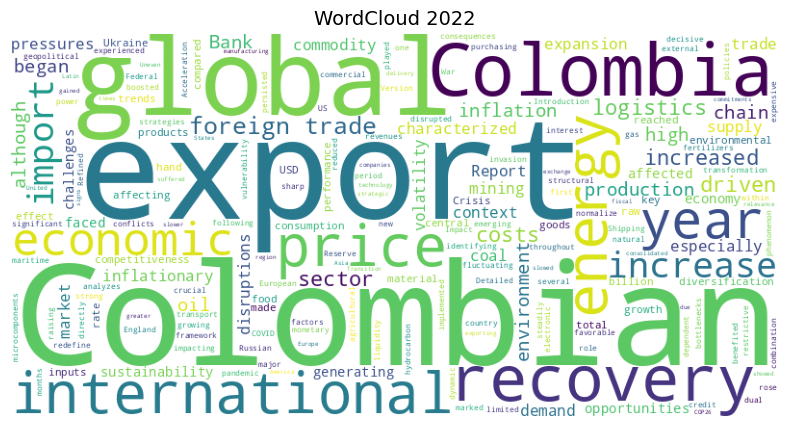

In [ ]:
# Generar nube de palabras para el mismo año

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(texto)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.title(f"WordCloud {anio}", fontsize=14)
plt.axis("off")
plt.show()


##Análisis Año 2023

In [ ]:
anio = "2023"
archivo = f"/content/InformeANALDEX_{anio}_EN.txt"

print(f"\n===== Analyzing {anio} =====")

# Cargar el texto
with open(archivo, "r", encoding="utf-8", errors="replace") as f:
    texto = f.read()

# Limpiar caracteres no ASCII
texto = texto.encode("ascii", "ignore").decode()

# Tokenización por frases
tks = sent_tokenize(texto)

# Matriz de categorías
nd = np.zeros((11, 1))  # Número de frases por sentimiento

for sent in tks:
    print("")
    print("Frase:", sent)

    score = sia.polarity_scores(sent)
    print("Polaridad:", score)  # Muestra el diccionario completo

    print("Puntuación:", score['compound'])  # Polaridad consolidada

    # Identificar categoría más cercana según el valor compound
    cat = np.abs(pol - score['compound'])
    catn = np.argmin(cat)

    print("Categoría PANAS-tDL:", cols[catn])


    nd[catn] += 1

# Corrección de neutrales
nd[5] = (nd[4] + nd[6]) / 2

# Crear DataFrame de resultados
df = pd.DataFrame(nd.T, columns=cols)

print("\nResultado general del año", anio)
display(df)

anio = "2023"

df_2023 = df.copy()


===== Analyzing 2023 =====

Frase: Detailed Report on Colombia's Foreign Trade in 2023 (Refined Version)

1.
Polaridad: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Puntuación: 0.0
Categoría PANAS-tDL: Neutral

Frase: Introduction
The year 2023 represented a turning point for Colombian foreign trade, characterized by a challenging global economic environment and a structural reconfiguration of international trade relations.
Polaridad: {'neg': 0.0, 'neu': 0.942, 'pos': 0.058, 'compound': 0.1531}
Puntuación: 0.1531
Categoría PANAS-tDL: Favorable

Frase: Despite the persistent effects of the COVID-19 pandemic and tensions arising from geopolitical conflicts, particularly the war in Ukraine and global energy instability, Colombia managed to maintain a relatively stable performance in its exports and imports, showing signs of resilience and productive adaptation.
Polaridad: {'neg': 0.183, 'neu': 0.734, 'pos': 0.083, 'compound': -0.7334}
Puntuación: -0.7334
Categoría PANAS-tDL: Pes

,Amenaza,Pesimismo,Inestabilidad,Escepticismo,Indiferente,Neutral,Favorable,Optimismo,Convicción,Consolidado,Confianza
0,0.0,2.0,0.0,0.0,2.0,3.5,5.0,2.0,7.0,1.0,0.0


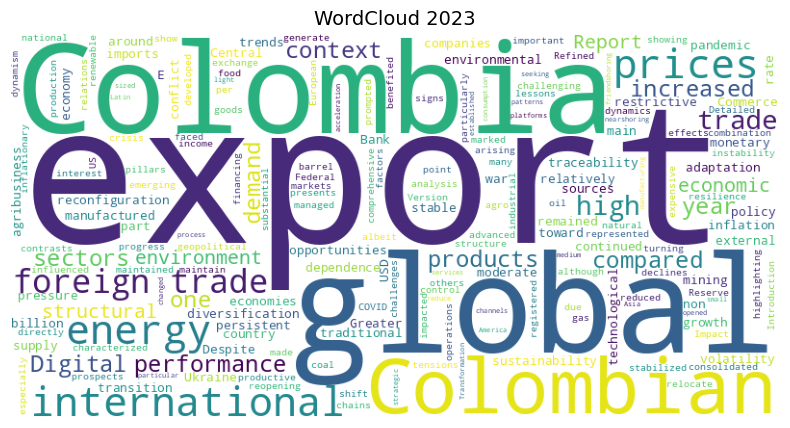

In [ ]:
# Generar nube de palabras para el mismo año

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(texto)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.title(f"WordCloud {anio}", fontsize=14)
plt.axis("off")
plt.show()

#Análisis Año 2024

In [ ]:
# Análisis de sentimientos detallado por frase

anio = "2024"
archivo = f"/content/InformeANALDEX_{anio}_EN.txt"

print(f"\n===== Analyzing {anio} =====")

# Cargar el texto
with open(archivo, "r", encoding="utf-8", errors="replace") as f:
    texto = f.read()

# Limpiar caracteres no ASCII
texto = texto.encode("ascii", "ignore").decode()

# Tokenización por frases
tks = sent_tokenize(texto)

# Matriz de categorías
nd = np.zeros((11, 1))  # Número de frases por sentimiento

for sent in tks:
    print("")
    print("Frase:", sent)

    score = sia.polarity_scores(sent)
    print("Polaridad:", score)  # Muestra el diccionario completo

    print("Puntuación:", score['compound'])  # Polaridad consolidada

    # Identificar categoría más cercana según el valor compound
    cat = np.abs(pol - score['compound'])
    catn = np.argmin(cat)

    print("Categoría PANAS-tDL:", cols[catn])

    nd[catn] += 1

# Corrección de neutrales
nd[5] = (nd[4] + nd[6]) / 2

# Crear DataFrame de resultados
df = pd.DataFrame(nd.T, columns=cols)

print("\nResultado general del año", anio)
display(df)

anio = "2024"
df_2024 = df.copy()


===== Analyzing 2024 =====

Frase: Detailed Report on Colombia's Foreign Trade in 2024

1.
Polaridad: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Puntuación: 0.0
Categoría PANAS-tDL: Neutral

Frase: Introduction
The year 2024 represented a period of consolidation and adjustments in Colombian foreign trade, amid an international landscape that continued to be complex and changing.
Polaridad: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Puntuación: 0.0
Categoría PANAS-tDL: Neutral

Frase: After years of post-pandemic recovery and the persistent effects of global inflation and geopolitical conflicts, Colombia faced an environment characterized by the global economic slowdown, the energy transition, the accelerated digitalization of trade, and the search for sustainability in production chains.
Polaridad: {'neg': 0.059, 'neu': 0.892, 'pos': 0.048, 'compound': -0.128}
Puntuación: -0.128
Categoría PANAS-tDL: Indiferente

Frase: Colombian foreign trade showed signs of mode

,Amenaza,Pesimismo,Inestabilidad,Escepticismo,Indiferente,Neutral,Favorable,Optimismo,Convicción,Consolidado,Confianza
0,0.0,1.0,0.0,1.0,3.0,2.0,1.0,6.0,5.0,3.0,0.0


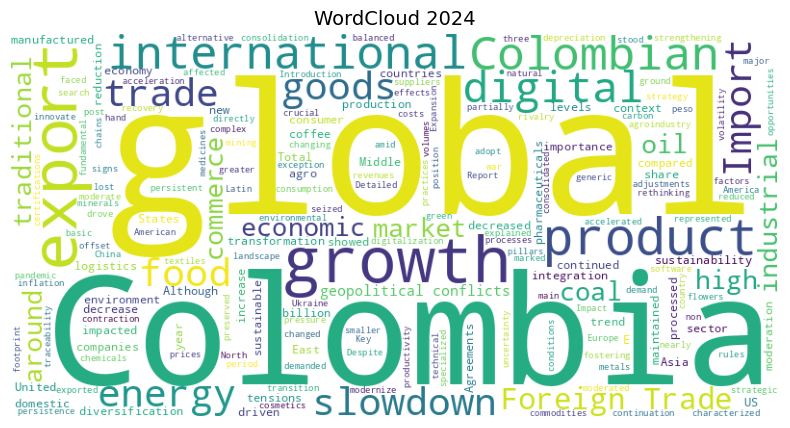

In [ ]:
# Generar nube de palabras para el mismo año

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(texto)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.title(f"WordCloud {anio}", fontsize=14)
plt.axis("off")
plt.show()

##Análisis Año 2025

In [ ]:
# Análisis de sentimientos detallado por frase

anio = "2025"
archivo = f"/content/InformeANALDEX_{anio}_EN.txt"

print(f"\n===== Analyzing {anio} =====")

# Cargar el texto
with open(archivo, "r", encoding="utf-8", errors="replace") as f:
    texto = f.read()

# Limpiar caracteres no ASCII
texto = texto.encode("ascii", "ignore").decode()

# Tokenización por frases
tks = sent_tokenize(texto)

# Matriz para categorías
nd = np.zeros((11, 1))  # Número de frases por sentimiento

for sent in tks:
    print("")
    print("Frase:", sent)

    score = sia.polarity_scores(sent)
    print("Polaridad:", score)  # Muestra el diccionario completo

    print("Puntuación:", score['compound'])  # Polaridad consolidada

    # Identificar categoría más cercana según el valor compound
    cat = np.abs(pol - score['compound'])
    catn = np.argmin(cat)

    print("Categoría PANAS-tDL:", cols[catn])

    nd[catn] += 1

# Corrección de neutrales
nd[5] = (nd[4] + nd[6]) / 2

# Crear DataFrame de resultados
df = pd.DataFrame(nd.T, columns=cols)

print("\nResultado general del año", anio)
display(df)

anio = "2025"
df_2025 = df.copy()


===== Analyzing 2025 =====

Frase: 
Detailed Report on Colombia's Foreign Trade in 2025

1.
Polaridad: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
Puntuación: 0.0
Categoría PANAS-tDL: Neutral

Frase: Introduction
The year 2025 consolidated a structural change in the dynamics of Colombian foreign trade, marked by the stabilization of international markets, the consolidation of the digital economy, and sustained progress toward the energy transition.
Polaridad: {'neg': 0.0, 'neu': 0.821, 'pos': 0.179, 'compound': 0.7184}
Puntuación: 0.7184
Categoría PANAS-tDL: Consolidado

Frase: After several years of volatility stemming from the pandemic, global inflation, and geopolitical conflicts, Colombia experienced a more predictable environment, although not without challenges.
Polaridad: {'neg': 0.101, 'neu': 0.854, 'pos': 0.045, 'compound': -0.3476}
Puntuación: -0.3476
Categoría PANAS-tDL: Escepticismo

Frase: In this scenario, Colombian exports showed a significant recovery: the re

,Amenaza,Pesimismo,Inestabilidad,Escepticismo,Indiferente,Neutral,Favorable,Optimismo,Convicción,Consolidado,Confianza
0,0.0,0.0,2.0,2.0,3.0,6.0,9.0,14.0,15.0,11.0,1.0


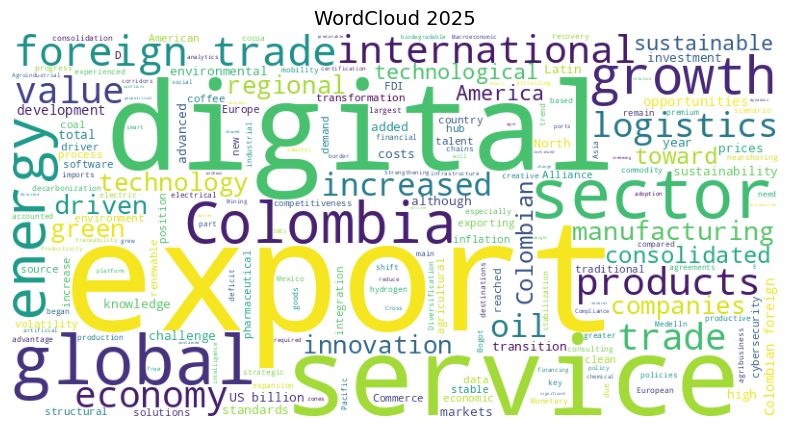

In [ ]:
# Generar nube de palabras para el mismo año

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis'
).generate(texto)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.title(f"WordCloud {anio}", fontsize=14)
plt.axis("off")
plt.show()

##Comparación de resultados entre años

In [ ]:
# Guardar los resultados individuales en un diccionario

resultados = {}

# Guarda cada DataFrame en el diccionario
resultados["2022"] = df_2022
resultados["2023"] = df_2023
resultados["2024"] = df_2024
resultados["2025"] = df_2025



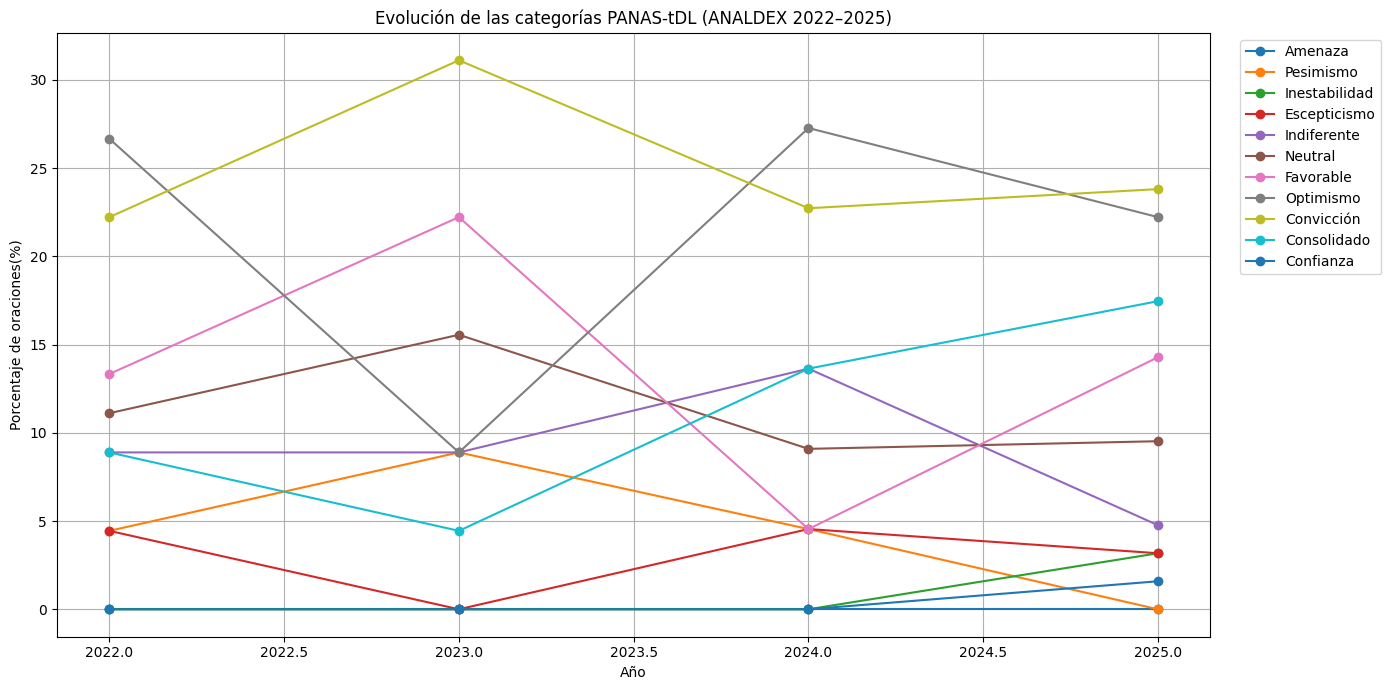


Tabla: Conteo por años


,Amenaza,Pesimismo,Inestabilidad,Escepticismo,Indiferente,Neutral,Favorable,Optimismo,Convicción,Consolidado,Confianza
2022,0.0,1.0,0.0,1.0,2.0,2.5,3.0,6.0,5.0,2.0,0.0
2023,0.0,2.0,0.0,0.0,2.0,3.5,5.0,2.0,7.0,1.0,0.0
2024,0.0,1.0,0.0,1.0,3.0,2.0,1.0,6.0,5.0,3.0,0.0
2025,0.0,0.0,2.0,2.0,3.0,6.0,9.0,14.0,15.0,11.0,1.0



Tabla: Distribución porcentual por año


,Amenaza,Pesimismo,Inestabilidad,Escepticismo,Indiferente,Neutral,Favorable,Optimismo,Convicción,Consolidado,Confianza
2022,0.0,4.44,0.00,4.44,8.89,11.11,13.33,26.67,22.22,8.89,0.00
2023,0.0,8.89,0.00,0.00,8.89,15.56,22.22,8.89,31.11,4.44,0.00
2024,0.0,4.55,0.00,4.55,13.64,9.09,4.55,27.27,22.73,13.64,0.00
2025,0.0,0.00,3.17,3.17,4.76,9.52,14.29,22.22,23.81,17.46,1.59


In [ ]:
# Comparación entre años
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Convertir a DataFrame con fila por año
df_all = pd.DataFrame([
    resultados["2022"].iloc[0].values,
    resultados["2023"].iloc[0].values,
    resultados["2024"].iloc[0].values,
    resultados["2025"].iloc[0].values
], columns=resultados["2022"].columns, index=[2022,2023,2024,2025])

# Calcular porcentajes por año
df_pct = df_all.div(df_all.sum(axis=1), axis=0) * 100

# Gráfico: una línea por categoría
plt.figure(figsize=(14,7))
for col in df_pct.columns:
    plt.plot(df_pct.index, df_pct[col], marker='o', label=col)
plt.title("Evolución de las categorías PANAS-tDL (ANALDEX 2022–2025)")
plt.xlabel("Año")
plt.ylabel("Porcentaje de oraciones(%)")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\nTabla: Conteo por años")
display(df_all)

print("\nTabla: Distribución porcentual por año")
display(df_pct.round(2))


##Palabras mas frecuentes del 2022

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



 Top 20 palabras más frecuentes por año(2022)
colombian       8
trade           7
global          7
recovery        6
international   6
energy          6
foreign         5
year            5
economic        5
prices          5
exports         5
increase        5
driven          4
logistics       4
costs           4
increased       4
imports         4
colombias       3
oil             3
inflation       3


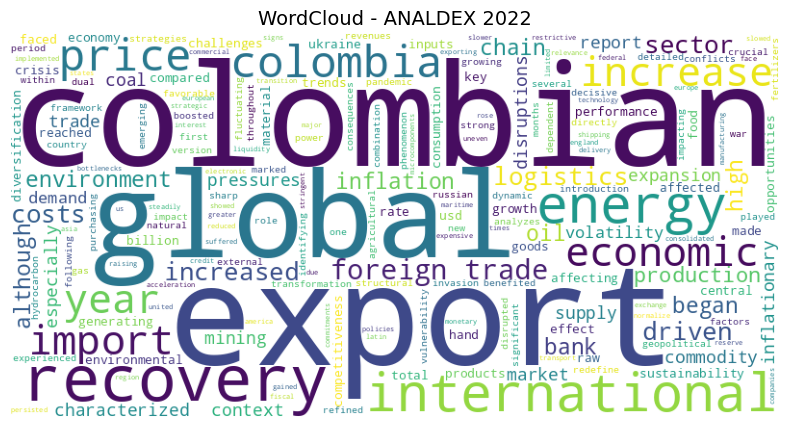

In [ ]:
# Palabras clave y temas dominantes (2022)
from nltk.corpus import stopwords
from collections import Counter
import string
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk

# Descargar las stopwords si no están ya descargadas.
# Esto es necesario para filtrar palabras comunes que no aportan significado al análisis.
nltk.download("stopwords")
# Cargar el conjunto de stopwords en inglés
stop_words = set(stopwords.words("english"))

# Define el año para el análisis
anio = "2022"
# Define la ruta del archivo de texto traducido al inglés para el año especificado
archivo = f"/content/InformeANALDEX_{anio}_EN.txt"

# Abre y lee el contenido del archivo de texto
# 'encoding="utf-8"' especifica la codificación para manejar caracteres especiales
# 'errors="replace"' maneja posibles errores de codificación reemplazando caracteres
with open(archivo, "r", encoding="utf-8", errors="replace") as f:
    texto = f.read() # Lee todo el contenido del archivo en la variable 'texto'

# Limpia el texto para prepararlo para el análisis
# .encode("ascii", "ignore") intenta codificar el texto a ASCII, ignorando caracteres no ASCII
# .decode() decodifica el resultado de vuelta a una cadena de texto
texto = texto.encode("ascii", "ignore").decode().lower() # Convierte el texto a minúsculas
# Crea una tabla de traducción que mapea cada signo de puntuación a None
# .translate() aplica la tabla de traducción para eliminar los signos de puntuación
texto = texto.translate(str.maketrans("", "", string.punctuation))

# Tokeniza el texto (divide en palabras) y filtra
# .split() divide la cadena de texto en una lista de palabras usando espacios como delimitador
# Se crea una lista 'palabras' que contiene solo palabras alfabéticas (sin números ni símbolos)
# y que no están en la lista de 'stop_words' (palabras muy comunes sin mucho significado)
palabras = [p for p in texto.split() if p.isalpha() and p not in stop_words]

# Cuenta la frecuencia de cada palabra
contador = Counter(palabras) # Crea un objeto Counter para contar las ocurrencias de cada palabra
# Obtiene las 20 palabras más comunes y su frecuencia
top_20 = contador.most_common(20)

# Imprime las 20 palabras más frecuentes
print(f"\n Top 20 palabras más frecuentes por año({anio})")
for palabra, freq in top_20:
    # Imprime cada palabra alineada a la izquierda y su frecuencia
    print(f"{palabra:<15} {freq}")

# Genera una nube de palabras (WordCloud)
# Configura el tamaño, color de fondo y mapa de color de la nube de palabras
# .generate() crea la nube de palabras a partir de una cadena de texto (las palabras filtradas unidas por espacios)
wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate(" ".join(palabras))

# Muestra la nube de palabras
plt.figure(figsize=(10,5)) # Crea una figura para el gráfico
plt.imshow(wordcloud) # Muestra la imagen de la nube de palabras
plt.title(f"WordCloud - ANALDEX {anio}", fontsize=14) # Establece el título del gráfico
plt.axis("off") # Desactiva los ejes para una mejor visualización de la nube de palabras
plt.show() # Muestra el gráfico

##Palabras mas frecuentes del 2023


 Top 20 palabras más frecuentes (2023)
trade           10
global          7
foreign         6
colombian       6
international   6
energy          6
prices          6
colombia        4
exports         4
export          4
high            4
year            3
performance     3
one             3
products        3
context         3
sectors         3
increased       3
compared        3
digital         3


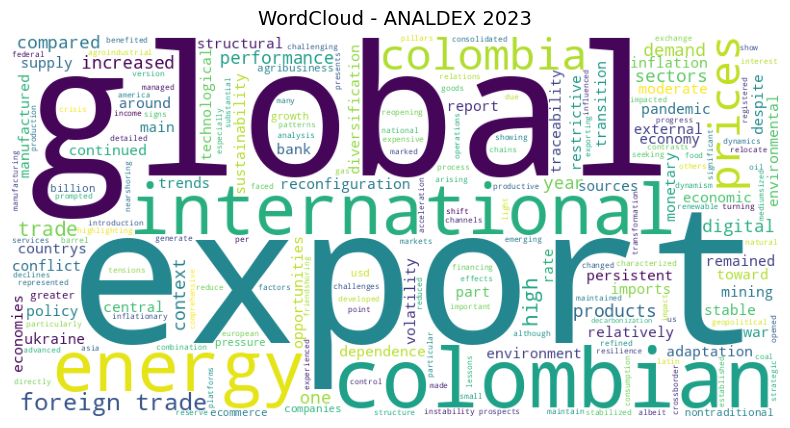

In [ ]:
# Palabras clave y temas dominantes (2023)

# Define el año para el análisis
anio = "2023"
# Define la ruta del archivo de texto traducido al inglés para el año especificado
archivo = f"/content/InformeANALDEX_{anio}_EN.txt"

# Abre y lee el contenido del archivo de texto
# 'encoding="utf-8"' especifica la codificación para manejar caracteres especiales
# 'errors="replace"' maneja posibles errores de codificación reemplazando caracteres
with open(archivo, "r", encoding="utf-8", errors="replace") as f:
    texto = f.read() # Lee todo el contenido del archivo en la variable 'texto'

# Limpia el texto para prepararlo para el análisis
# .encode("ascii", "ignore") intenta codificar el texto a ASCII, ignorando caracteres no ASCII
# .decode() decodifica el resultado de vuelta a una cadena de texto
texto = texto.encode("ascii", "ignore").decode().lower() # Convierte el texto a minúsculas
# Crea una tabla de traducción que mapea cada signo de puntuación a None
# .translate() aplica la tabla de traducción para eliminar los signos de puntuación
texto = texto.translate(str.maketrans("", "", string.punctuation))

# Tokeniza el texto (divide en palabras) y filtra
# .split() divide la cadena de texto en una lista de palabras usando espacios como delimitador
# Se crea una lista 'palabras' que contiene solo palabras alfabéticas (sin números ni símbolos)
# y que no están en la lista de 'stop_words' (palabras muy comunes sin mucho significado)
palabras = [p for p in texto.split() if p.isalpha() and p not in stop_words]

# Cuenta la frecuencia de cada palabra
contador = Counter(palabras) # Crea un objeto Counter para contar las ocurrencias de cada palabra
# Obtiene las 20 palabras más comunes y su frecuencia
top_20 = contador.most_common(20)

# Imprime las 20 palabras más frecuentes
print(f"\n Top 20 palabras más frecuentes ({anio})")
for palabra, freq in top_20:
    # Imprime cada palabra alineada a la izquierda y su frecuencia
    print(f"{palabra:<15} {freq}")

# Genera una nube de palabras (WordCloud)
# Configura el tamaño, color de fondo y mapa de color de la nube de palabras
# .generate() crea la nube de palabras a partir de una cadena de texto (las palabras filtradas unidas por espacios)
wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate(" ".join(palabras))

# Muestra la nube de palabras
plt.figure(figsize=(10,5)) # Crea una figura para el gráfico
plt.imshow(wordcloud) # Muestra la imagen de la nube de palabras
plt.title(f"WordCloud - ANALDEX {anio}", fontsize=14) # Establece el título del gráfico
plt.axis("off") # Desactiva los ejes para una mejor visualización de la nube de palabras
plt.show() # Muestra el gráfico

##Palabras mas frecuentes del 2024


 Top 20 palabras más frecuentes(2024)
global          9
trade           8
growth          6
colombian       5
international   5
digital         5
foreign         4
colombia        4
slowdown        4
energy          4
exports         4
goods           4
products        4
geopolitical    3
conflicts       3
economic        3
high            3
oil             3
coal            3
imports         3


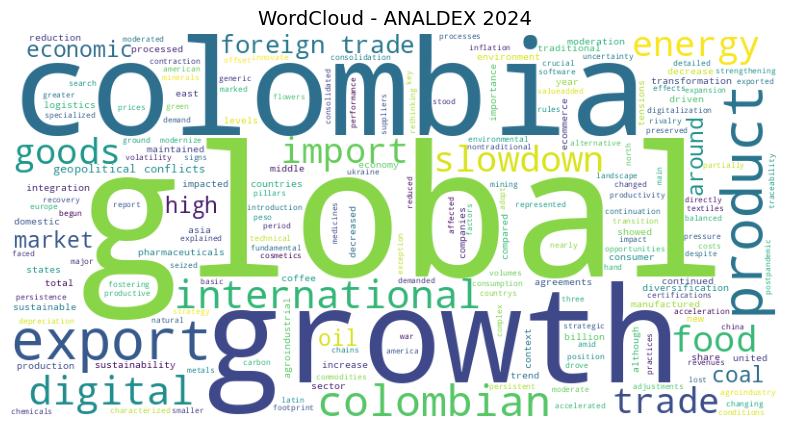

In [ ]:
# Palabras clave y temas dominantes (2024)

# Define el año para el análisis
anio = "2024"
# Define la ruta del archivo de texto traducido al inglés para el año especificado
archivo = f"/content/InformeANALDEX_{anio}_EN.txt"

# Abre y lee el contenido del archivo de texto
# 'encoding="utf-8"' especifica la codificación para manejar caracteres especiales
# 'errors="replace"' maneja posibles errores de codificación reemplazando caracteres
with open(archivo, "r", encoding="utf-8", errors="replace") as f:
    texto = f.read() # Lee todo el contenido del archivo en la variable 'texto'

# Limpia el texto para prepararlo para el análisis
# .encode("ascii", "ignore") intenta codificar el texto a ASCII, ignorando caracteres no ASCII
# .decode() decodifica el resultado de vuelta a una cadena de texto
texto = texto.encode("ascii", "ignore").decode().lower() # Convierte el texto a minúsculas
# Crea una tabla de traducción que mapea cada signo de puntuación a None
# .translate() aplica la tabla de traducción para eliminar los signos de puntuación
texto = texto.translate(str.maketrans("", "", string.punctuation))

# Tokeniza el texto (divide en palabras) y filtra
# .split() divide la cadena de texto en una lista de palabras usando espacios como delimitador
# Se crea una lista 'palabras' que contiene solo palabras alfabéticas (sin números ni símbolos)
# y que no están en la lista de 'stop_words' (palabras muy comunes sin mucho significado)
palabras = [p for p in texto.split() if p.isalpha() and p not in stop_words]

# Cuenta la frecuencia de cada palabra
contador = Counter(palabras) # Crea un objeto Counter para contar las ocurrencias de cada palabra
# Obtiene las 20 palabras más comunes y su frecuencia
top_20 = contador.most_common(20)

# Imprime las 20 palabras más frecuentes
print(f"\n Top 20 palabras más frecuentes({anio})")
for palabra, freq in top_20:
    # Imprime cada palabra alineada a la izquierda y su frecuencia
    print(f"{palabra:<15} {freq}")

# Genera una nube de palabras (WordCloud)
# Configura el tamaño, color de fondo y mapa de color de la nube de palabras
# .generate() crea la nube de palabras a partir de una cadena de texto (las palabras filtradas unidas por espacios)
wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate(" ".join(palabras))

# Muestra la nube de palabras
plt.figure(figsize=(10,5)) # Crea una figura para el gráfico
plt.imshow(wordcloud) # Muestra la imagen de la nube de palabras
plt.title(f"WordCloud - ANALDEX {anio}", fontsize=14) # Establece el título del gráfico
plt.axis("off") # Desactiva los ejes para una mejor visualización de la nube de palabras
plt.show() # Muestra el gráfico

##Palabras mas frecuentes del 2025


 Top 20 palabras más frecuentes por años (2025)
trade           16
exports         14
digital         13
global          12
energy          11
services        11
foreign         10
colombian       10
colombia        10
growth          9
international   8
products        8
export          8
sector          8
economy         7
logistics       7
increased       6
manufacturing   6
technology      6
green           6


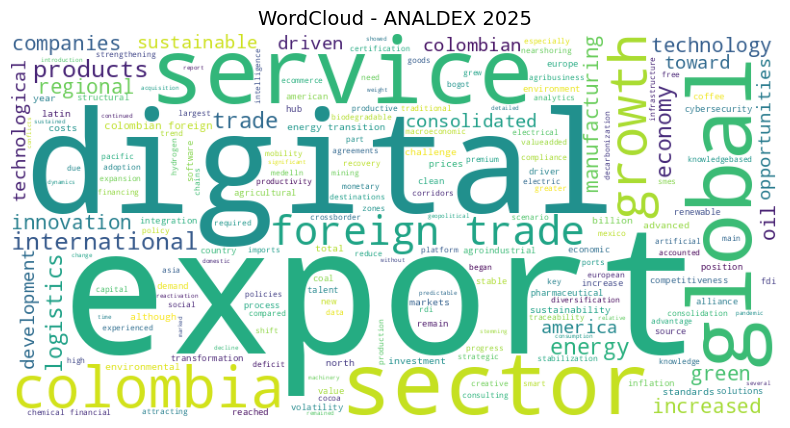

In [ ]:
# Palabras clave y temas dominantes (2025)

# Define el año para el análisis
anio = "2025"
# Define la ruta del archivo de texto traducido al inglés para el año especificado
archivo = f"/content/InformeANALDEX_{anio}_EN.txt"

# Abre y lee el contenido del archivo de texto
# 'encoding="utf-8"' especifica la codificación para manejar caracteres especiales
# 'errors="replace"' maneja posibles errores de codificación reemplazando caracteres
with open(archivo, "r", encoding="utf-8", errors="replace") as f:
    texto = f.read() # Lee todo el contenido del archivo en la variable 'texto'

# Limpia el texto para prepararlo para el análisis
# .encode("ascii", "ignore") intenta codificar el texto a ASCII, ignorando caracteres no ASCII
# .decode() decodifica el resultado de vuelta a una cadena de texto
texto = texto.encode("ascii", "ignore").decode().lower() # Convierte el texto a minúsculas
# Crea una tabla de traducción que mapea cada signo de puntuación a None
# .translate() aplica la tabla de traducción para eliminar los signos de puntuación
texto = texto.translate(str.maketrans("", "", string.punctuation))

# Tokeniza el texto (divide en palabras) y filtra
# .split() divide la cadena de texto en una lista de palabras usando espacios como delimitador
# Se crea una lista 'palabras' que contiene solo palabras alfabéticas (sin números ni símbolos)
# y que no están en la lista de 'stop_words' (palabras muy comunes sin mucho significado)
palabras = [p for p in texto.split() if p.isalpha() and p not in stop_words]

# Cuenta la frecuencia de cada palabra
contador = Counter(palabras) # Crea un objeto Counter para contar las ocurrencias de cada palabra
# Obtiene las 20 palabras más comunes y su frecuencia
top_20 = contador.most_common(20)

# Imprime las 20 palabras más frecuentes
print(f"\n Top 20 palabras más frecuentes por años ({anio})")
for palabra, freq in top_20:
    # Imprime cada palabra alineada a la izquierda y su frecuencia
    print(f"{palabra:<15} {freq}")

# Genera una nube de palabras (WordCloud)
# Configura el tamaño, color de fondo y mapa de color de la nube de palabras
# .generate() crea la nube de palabras a partir de una cadena de texto (las palabras filtradas unidas por espacios)
wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate(" ".join(palabras))

# Muestra la nube de palabras
plt.figure(figsize=(10,5)) # Crea una figura para el gráfico
plt.imshow(wordcloud) # Muestra la imagen de la nube de palabras
plt.title(f"WordCloud - ANALDEX {anio}", fontsize=14) # Establece el título del gráfico
plt.axis("off") # Desactiva los ejes para una mejor visualización de la nube de palabras
plt.show() # Muestra el gráfico

##**Conclusiones**


El análisis de sentimiento aplicado a los informes de comercio exterior de Colombia entre 2022 y 2025 revela una narrativa en clara evolución, pasando de una cautela inicial marcada por la volatilidad global a una proyección de confianza y consolidación a largo plazo. A pesar de que 2022 y 2023 estuvieron dominados por el impacto de los shocks externos —con un énfasis en la "Recuperación" y la "Volatilidad" de precios de commodities como el petróleo, el carbón y la pandemia—, el sentimiento se mantuvo predominantemente positivo, impulsado por categorías de alta intención como el Optimismo (2022 y 2024) y la Convicción (pico en 2023).

El año 2023 representa un punto de inflexión. Si bien el sentimiento se tornó ligeramente más negativo en términos de Pesimismo debido a la caída en las exportaciones totales (que llegaron a experimentar contracciones significativas ese año) y las preocupaciones por la inflación global, la alta Convicción en los informes sugiere que esta perspectiva negativa estaba contrarrestada por la firmeza en las nuevas políticas y el impulso a la diversificación de productos y mercados. Es en este periodo que se consolidó la apuesta por las exportaciones no minero-energéticas (particularmente el crecimiento récord en exportaciones de servicios informáticos y el aumento de ventas a mercados no tradicionales como China y México), lo que fundamentó la sensación de certeza sobre la estrategia comercial en el mediano plazo.

La tendencia se reafirma y madura en el bienio 2024-2025, donde la conversación pivota hacia la sofisticación y el futuro digital. Los términos "Digital", "Service", "Innovation" y "Growth" se vuelven los motores del discurso, superando el foco en los commodities tradicionales. Este cambio temático se refleja en el sentimiento con un incremento constante de las categorías "Consolidado" y "Confianza", mientras que la Inestabilidad y el Pesimismo se reducen a niveles marginales. La conclusión es que, para 2025, el comercio exterior colombiano es visto no solo como un sector en crecimiento, sino como un pilar estable y diversificado de la economía, con una clara hoja de ruta enfocada en la tecnología y la exportación de valor agregado, cimentando una percepción de Confianza Estratégica.